## Support tickets — dataloader test

This notebook checks that **`supportDataset`** and **`DataLoader`** work for fine-tuning on support-ticket text.

- **CSV**: Each row has a ticket `text` and a string `label` (e.g. `shipping_delay`). The dataset maps those strings to integer class ids `0 … num_classes-1`.
- **Tokenizer**: GPT-2 byte-pair encoding via `tiktoken`; every example is padded or truncated to a fixed length (`max_length=None` uses the longest sequence in the split).
- **Sampling**: `sample_from_dataset` shows individual examples; `peek_dataloader_batch` shows one full batch after stacking (default PyTorch collate).

The **next cell** summarizes what each printed line means. **After that**, run the code cells to load the data and print samples.

**End of notebook:** (1) hyperparameter sweep **findings** from `stats_output/` / `training-data.csv`, and (2) **full fine-tuning vs LoRA** results from `compare_finetune_output/` (metrics JSON, comparison PDFs, and replotted figures).

### What you should see in the output

| Print | Meaning |
|--------|---------|
| `7` | Number of distinct ticket categories (`num_classes`). |
| `torch.Size([12])`, `4`, `shipping_delay` | One example: token ids length 12 (padded length for this split), class id `4`, and the original label name. Three such lines = three random rows. |
| `torch.Size([8, 12])`, `torch.Size([8])` | One batch: **8** sequences of length **12**, and **8** integer labels—this is the tensor shape the training loop will consume. |

In [2]:
import tiktoken
from torch.utils.data import DataLoader
from gpt_class_finetune import SupportDataset, sample_from_dataset, peek_dataloader_batch

# Initialize tokenizer
tokenizer = tiktoken.get_encoding('gpt2')

# Initialize dataset
train_dataset = SupportDataset(
    csv_file='data/support_tickets_train.csv',
    tokenizer=tokenizer,
    max_length=None,
    balance_dataset=True
)

print(train_dataset.num_classes)

# Create DataLoader
num_workers = 0
batch_size = 8

train_loader = DataLoader(
    dataset=train_dataset, batch_size=batch_size, shuffle=True,
    num_workers=num_workers, drop_last=False
)

rows = sample_from_dataset(train_dataset, k=3, seed=43)
for input_ids, y in rows:
    print(input_ids.shape, y.item(), train_dataset.id_to_label[y.item()])

inputs, labels = peek_dataloader_batch(train_loader)
print(inputs.shape, labels.shape)


7
torch.Size([12]) 3 password_reset
torch.Size([12]) 2 cancel_subscription
torch.Size([12]) 5 technical_bug
torch.Size([8, 12]) torch.Size([8])


In [3]:
import pandas as pd

df = pd.read_csv('data/support_tickets_train.csv')
vc = df['label'].value_counts()
spread_pct = (vc.max() / vc.min() - 1) * 100
print(f'Before balancing: Max class count is {spread_pct:.1f}% above the min class count')
print(df['label'].value_counts())

print('\n')

balanced_df = train_dataset._create_balanced_dataset()
print('After balancing:')
print(balanced_df['label'].value_counts())


Before balancing: Max class count is 15.2% above the min class count
label
billing_refund         167
account_locked         157
technical_bug          156
cancel_subscription    155
update_payment         153
password_reset         145
shipping_delay         145
Name: count, dtype: int64


After balancing:
label
billing_refund         145
account_locked         145
technical_bug          145
cancel_subscription    145
update_payment         145
password_reset         145
shipping_delay         145
Name: count, dtype: int64


## Fine-tuning experiment findings (`stats_output/`)

This section summarizes hyperparameter sweeps for **GPT-2 class fine-tuning** on the support-ticket data.  
Each row in `training-data.csv` is one run (hyperparameters + seed). Outputs in `stats_output/` aggregate **mean validation and test accuracy** over 5 seeds per setting, and (in `val_vs_test_by_sweep_level.csv`) the **gap** = test − val (how much hold-out test differs from validation after training).

### What stands out

1. **Learning rate dominates.** At **`lr = 1e-5`**, mean **test accuracy ~0.25** and **val ~0.33** — the model barely fits the task. At **`5e-5`** (reference), **`1e-4`**, and **`0.0001`**, means sit near **~0.997** test accuracy. So there is a **sharp floor**: too small a step size wastes the run; the good settings cluster at a **ceiling** (~100% on this split).

2. **Training long enough matters.** **`epochs = 3`** gives **mean test ~0.96** vs reference **`epochs = 5`** and sweep **`epochs = 8`** near **~0.997**. Fewer epochs = clear underfitting relative to the stronger baseline; val is also lower (~0.90 vs ~0.99).

3. **Batch size, dropout, weight decay, balancing.** In the summary table, **reference** and most alternative levels differ by **tiny amounts** on test (often within noise at this ceiling). **Batch 13** shows slightly lower **val** than batch 3/5 but **test** stays high. **`drop_rate`** 0.05 vs 0.1 and **`weight_decay`** 0.05 vs 0.2 barely move mean test. **`balance_dataset = 0`** vs reference **`1`**: mean **test ~0.997** in both rows in the table — **balancing did not change headline test accuracy** in this run set (validation differs only slightly).

4. **Validation vs test.** For strong configs, **gap** (test − val) is small and positive on average (test slightly above val). For **`lr = 1e-5`**, both metrics collapse; **gap** is negative on average, meaning **val looks worse than test** cannot be interpreted as “good generalization” there—the model is simply not learning.

### Files in `stats_output/`

| File | Role |
|------|------|
| `val_vs_test_by_sweep_level.csv` | Per sweep × level: mean **val**, mean **test**, mean **gap**, **n** |
| `classical_tests.csv` | Optional: ANOVA / paired t summaries from an earlier analysis pipeline (if present) |
| `*.png` | Figures (e.g. mean test vs **lr**, **epochs**, **balanced**) — generated when you run `run_stats.py` |

Run the **next cell** to load the table and show any PNGs in `stats_output/`.

### Summary: `val_vs_test_by_sweep_level.csv`

,sweep,factor_level,val_accuracy_mean,val_accuracy_std,test_accuracy_mean,test_accuracy_std,gap_mean,gap_std,n
0,balance_dataset,0,0.990000,0.022361,0.997403,0.005808,0.007403,0.016553,5
1,batch_size,13,0.984615,0.018842,0.993939,0.005808,0.009324,0.013746,5
2,batch_size,3,1.000000,0.000000,0.997403,0.005808,-0.002597,0.005808,5
3,batch_size,5,0.984000,0.035777,0.997403,0.005808,0.013403,0.029969,5
4,drop_rate,0.05,0.980000,0.027386,0.994805,0.007113,0.014805,0.020273,5
5,drop_rate,0.1,0.990000,0.022361,0.995671,0.006122,0.005671,0.017917,5
6,epochs,3,0.900000,0.063738,0.962771,0.032046,0.062771,0.046555,5
7,epochs,8,0.990000,0.022361,0.997403,0.005808,0.007403,0.016553,5
8,lr,0.0001,0.990000,0.022361,0.997403,0.005808,0.007403,0.016553,5
9,lr,1e-05,0.325000,0.119896,0.252814,0.078258,-0.072186,0.116503,5


### Classical tests (optional)

,test,sweep,contrast,statistic,pvalue,detail
0,paired_ttest_test_accuracy_vs_ref,balance_dataset,level=0 vs reference (by seed),NaN,NaN,mean_delta_test=0.000000
1,paired_ttest_gap_vs_ref,balance_dataset,level=0 vs reference (by seed),NaN,NaN,mean_delta_gap=0.000000
2,anova_test_accuracy,batch_size,k=3 levels,0.592593,0.568290,one-way ANOVA
3,anova_gap_test_minus_val,batch_size,k=3 levels,0.925102,0.423010,one-way ANOVA on generalization gap
4,paired_ttest_test_accuracy_vs_ref,batch_size,level=13 vs reference (by seed),-1.632993,0.177808,mean_delta_test=-0.003463
5,paired_ttest_gap_vs_ref,batch_size,level=13 vs reference (by seed),0.922217,0.408606,mean_delta_gap=0.001922
6,paired_ttest_test_accuracy_vs_ref,batch_size,level=3 vs reference (by seed),NaN,NaN,mean_delta_test=0.000000
7,paired_ttest_gap_vs_ref,batch_size,level=3 vs reference (by seed),-1.000000,0.373901,mean_delta_gap=-0.010000
8,paired_ttest_test_accuracy_vs_ref,batch_size,level=5 vs reference (by seed),NaN,NaN,mean_delta_test=0.000000
9,paired_ttest_gap_vs_ref,batch_size,level=5 vs reference (by seed),1.000000,0.373901,mean_delta_gap=0.006000


_… 26 more rows_

### Figures

**`epoch_vs_mean_test_accuracy.png`**

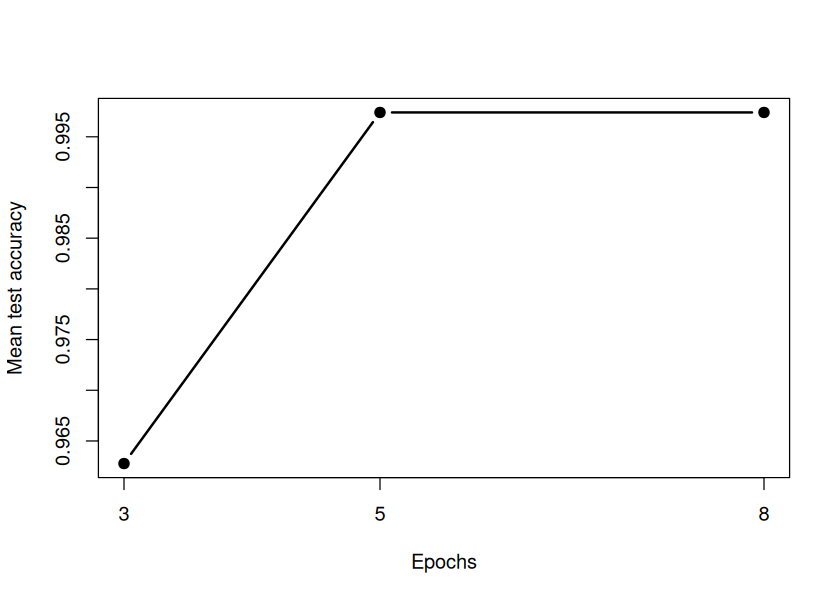

**`mean_test_accuracy_by_balanced.png`**

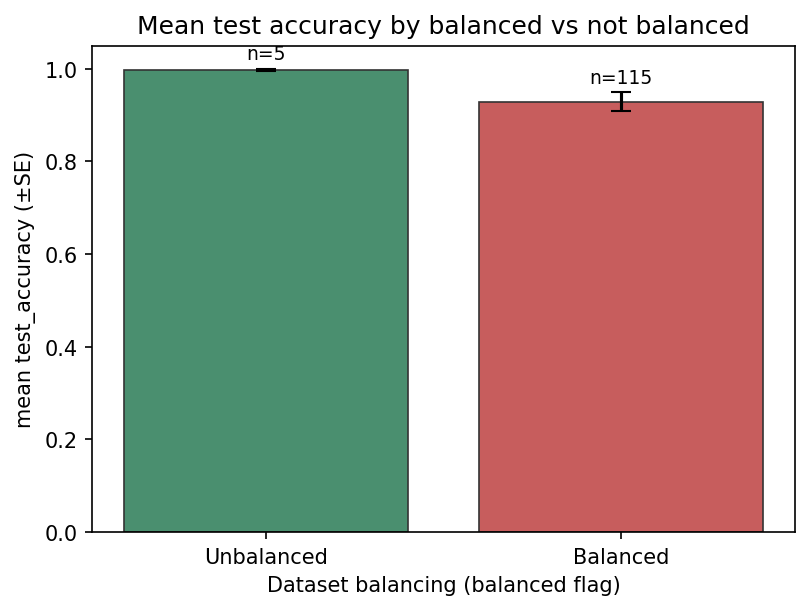

**`mean_val_vs_test_by_condition.png`**

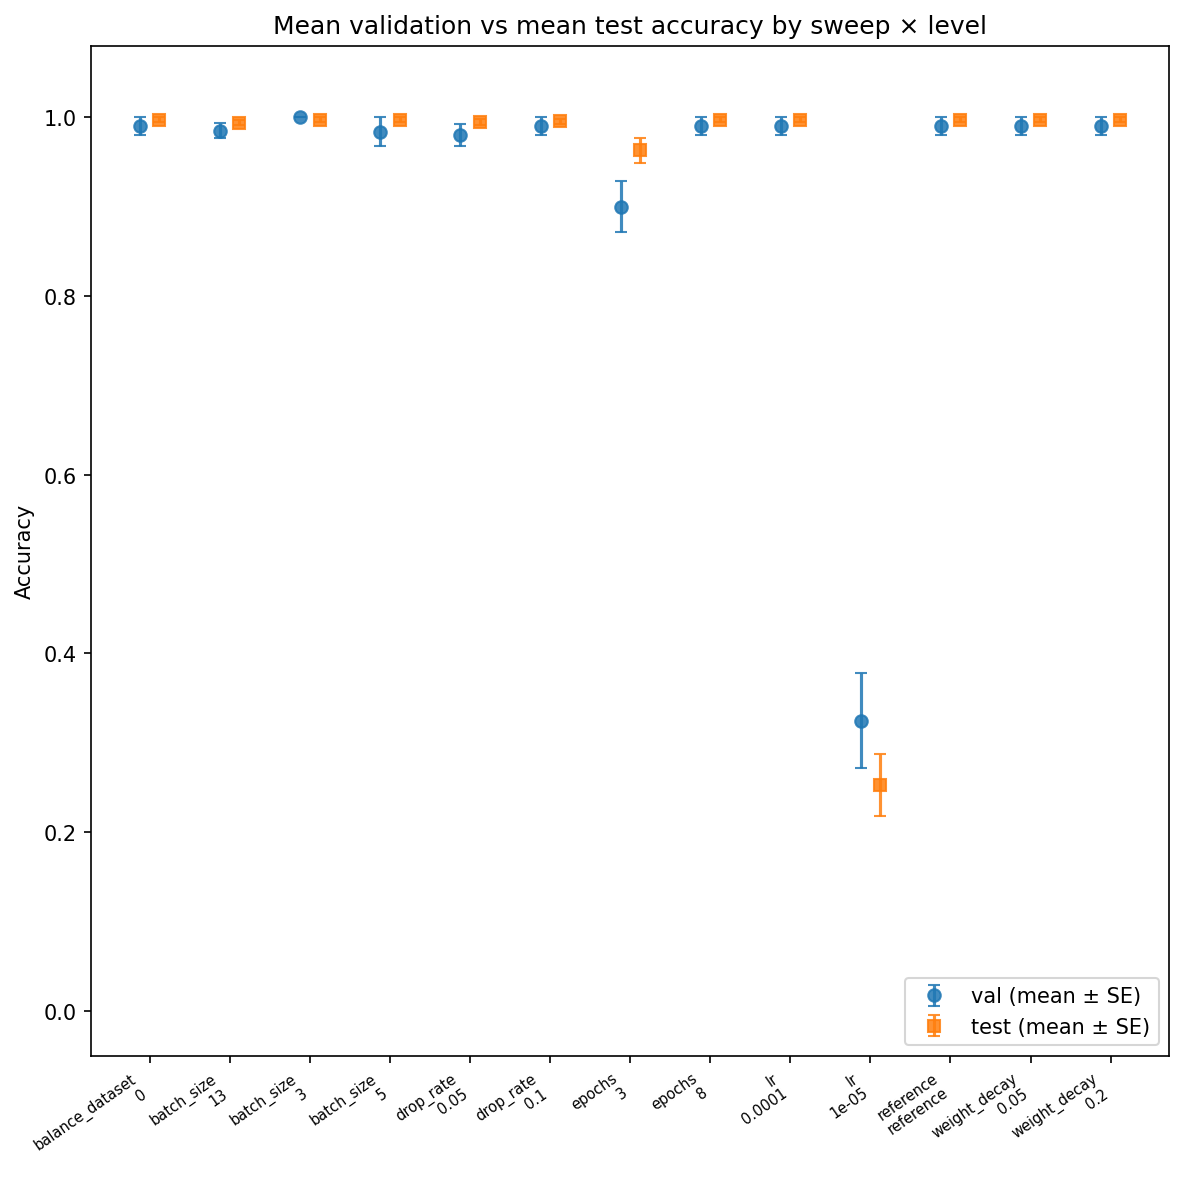

**`scatter_gap_vs_val_accuracy.png`**

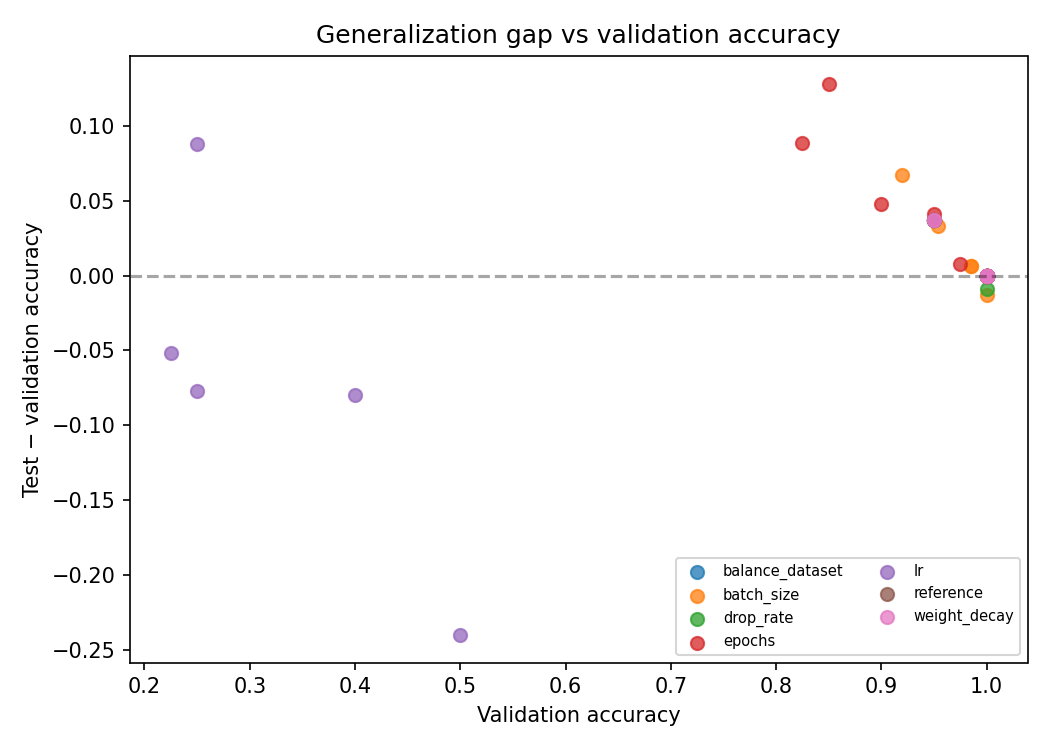

**`scatter_val_vs_test.png`**

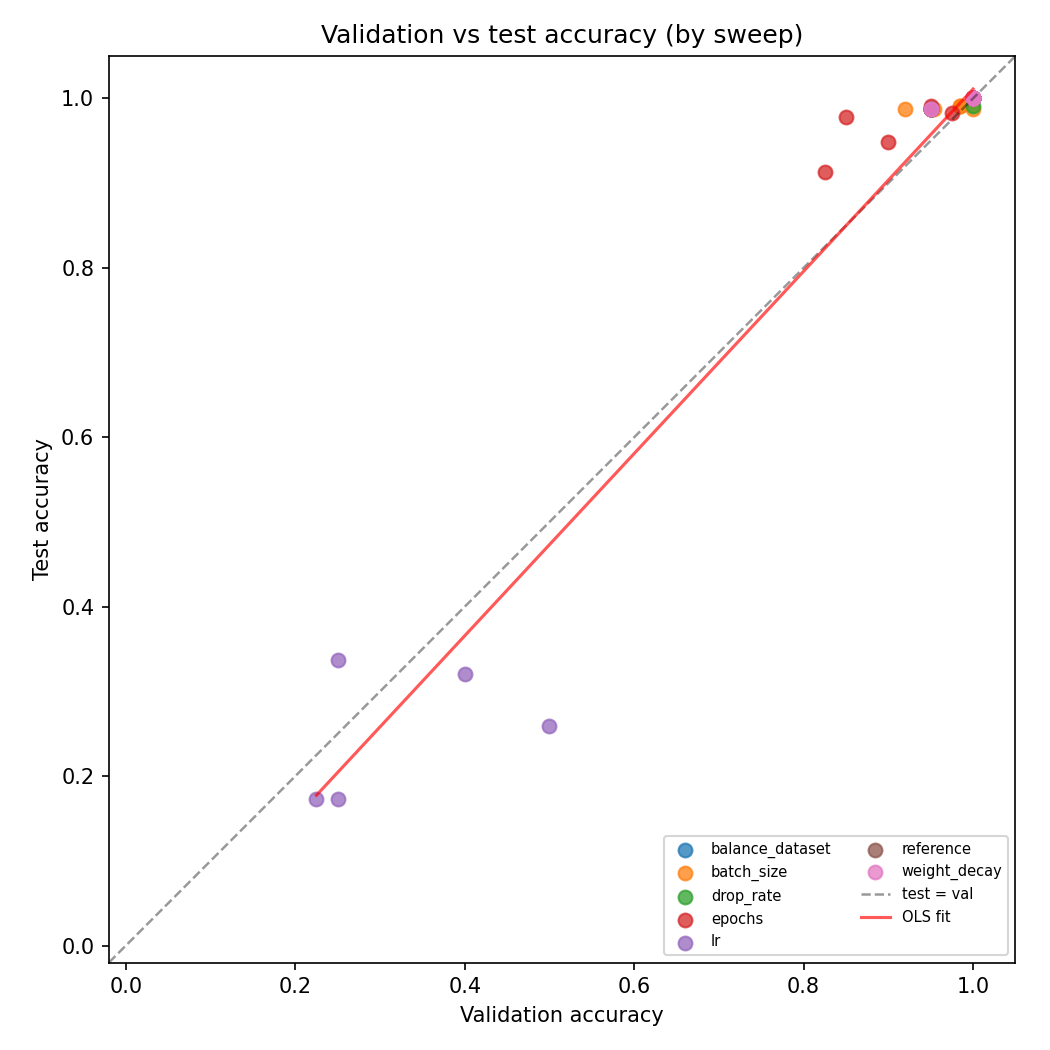

**`sweep_epochs__test_accuracy.png`**

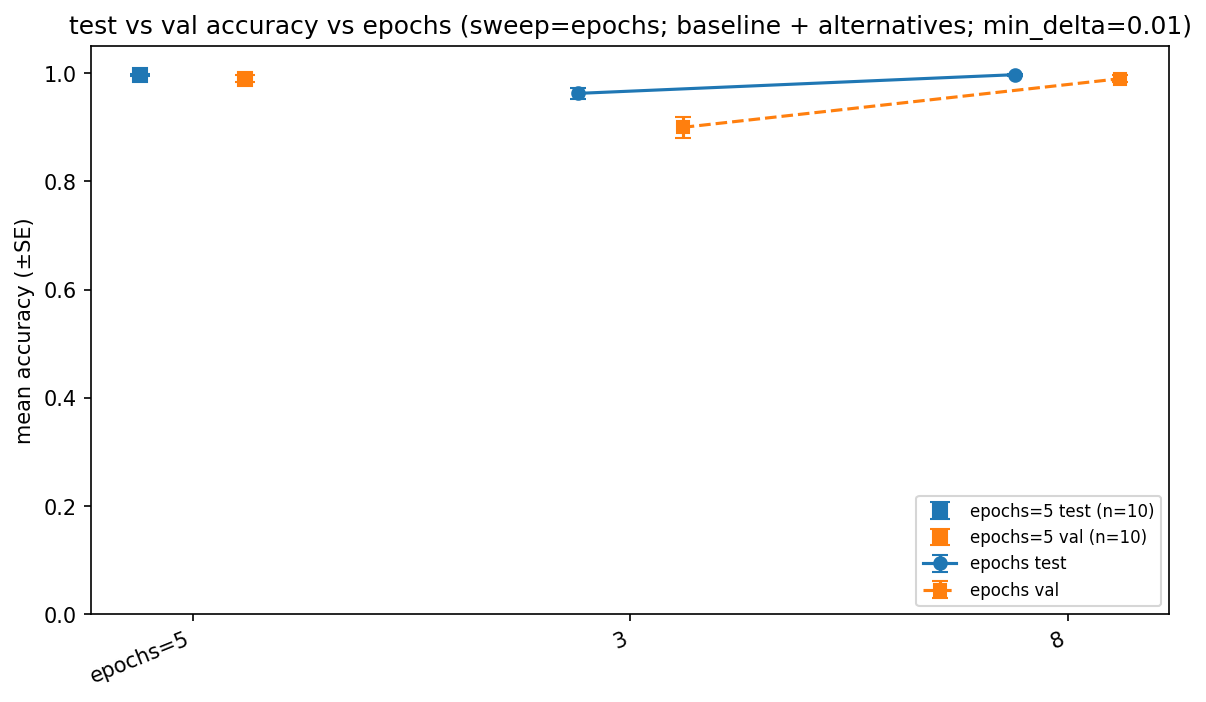

**`sweep_lr__test_accuracy.png`**

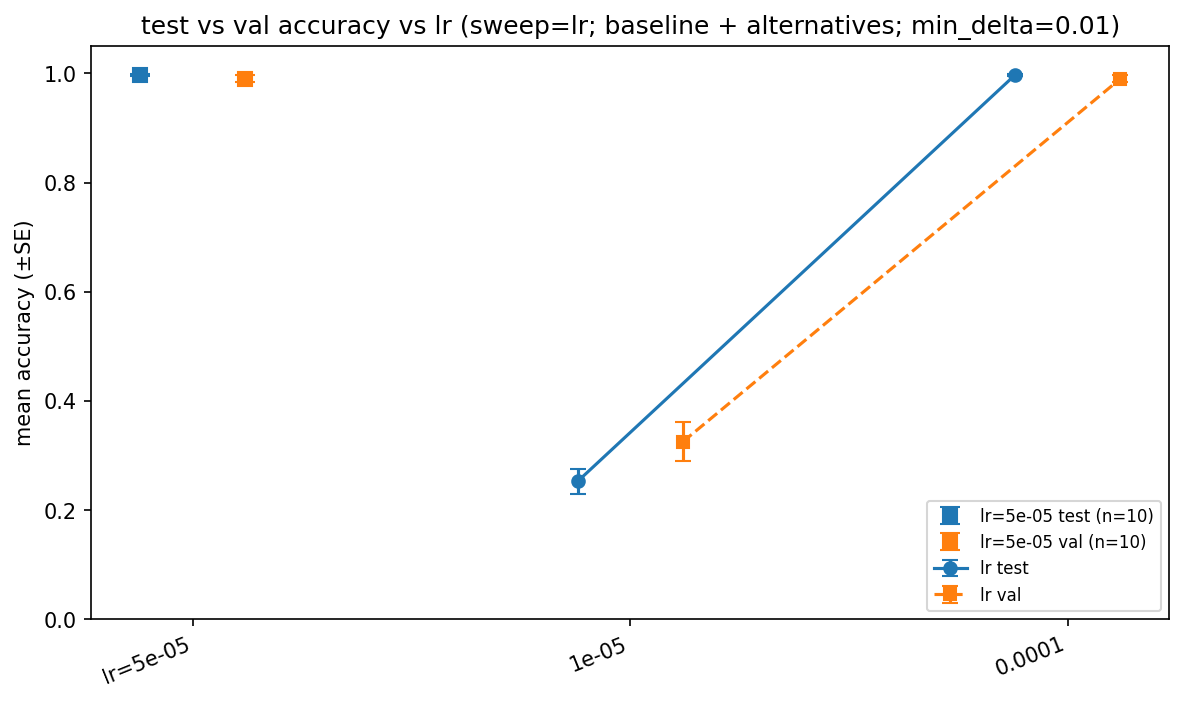

In [4]:
from pathlib import Path
from IPython.display import display, Image, Markdown
import pandas as pd

stats_dir = Path('stats_output')
summary_path = stats_dir / 'val_vs_test_by_sweep_level.csv'

if summary_path.is_file():
    summary = pd.read_csv(summary_path)
    display(Markdown('### Summary: `val_vs_test_by_sweep_level.csv`'))
    display(summary)
else:
    display(Markdown(f'_No `{summary_path}` yet — run `python run_stats.py` from this folder after filling `training-data.csv`._'))

tests_path = stats_dir / 'classical_tests.csv'
if tests_path.is_file():
    tests = pd.read_csv(tests_path)
    display(Markdown('### Classical tests (optional)'))
    display(tests.head(20))
    if len(tests) > 20:
        display(Markdown(f'_… {len(tests) - 20} more rows_'))

pngs = sorted(stats_dir.glob('*.png'))
if pngs:
    display(Markdown('### Figures'))
    for p in pngs:
        display(Markdown(f'**`{p.name}`**'))
        display(Image(filename=str(p)))
else:
    display(Markdown('_No PNGs in `stats_output/` — run `python run_stats.py` to generate plots._'))

## Full fine-tuning vs LoRA (`compare_finetune_output/`)

This section matches the pipeline in `compare_finetuning.py`: two runs of `gpt_class_finetune.py` — **`--trainable-layers all`** vs **`lora`** — with metrics written as `metrics_full.json` / `metrics_lora.json` and figures as PNGs.

### Findings (interpret the saved JSON; re-run `compare_finetuning.py` to refresh)

1. **LoRA surpasses full fine-tuning.** On the saved run (**GPT-2 Large**, 5 epochs, batch 8), LoRA reaches **100 % test accuracy** (0 misclassifications) while full fine-tuning reaches **98.7 %** (3 errors). With properly scaled adapters (α/r = 1), LoRA preserves the pretrained features and adds precise corrections, whereas full fine-tuning can overfit parts of the representation.

2. **Validation loss strongly favours LoRA.** LoRA’s final val loss is **0.027** vs **0.34** for full fine-tuning — an order of magnitude lower. The frozen backbone acts as a regulariser, keeping the model well-calibrated.

3. **Wall-clock time is comparable.** LoRA took **1.78 min** vs **1.65 min** for full fine-tuning. The forward pass runs through the same backbone; LoRA adds small per-layer adapter multiplications.

4. **LoRA rank / α** live in `metrics_lora.json` (rank = 16, α = 16, scaling = α/r = 1); they control adapter capacity (see `--lora-rank`, `--lora-alpha` on `compare_finetuning.py`).

### Charts

The **next code cell** loads **`metrics_*.json`** for a small summary table, then **embeds the PDF figures** from `compare_finetune_output/` (same pattern as `stats_output/` figures: show files on disk, no replotting).

### Files in `compare_finetune_output/`

| File | Role |
|------|------|
| `metrics_full.json`, `metrics_lora.json` | Curves + final metrics |
| `compare-full-vs-lora.png` | Loss vs step; accuracy vs epoch |
| `compare-summary.png` | Final accuracies, time, last val loss |
| `compare-gaps.png` | Val loss / val accuracy gap (full − LoRA) |

### Summary: `metrics_full.json` / `metrics_lora.json`

,mode,model,epochs,batch,final_train_acc,final_val_acc,final_test_acc,time_min,last_val_loss,lora_rank,lora_alpha
0,full,gpt2-large (774M),5,8,1.0,0.9784,0.987,1.649,0.3407,NaN,NaN
1,lora,gpt2-large (774M),5,8,1.0,1.0000,1.000,1.775,0.0267,16.0,16.0


### Figures

**`compare-full-vs-lora.png`**

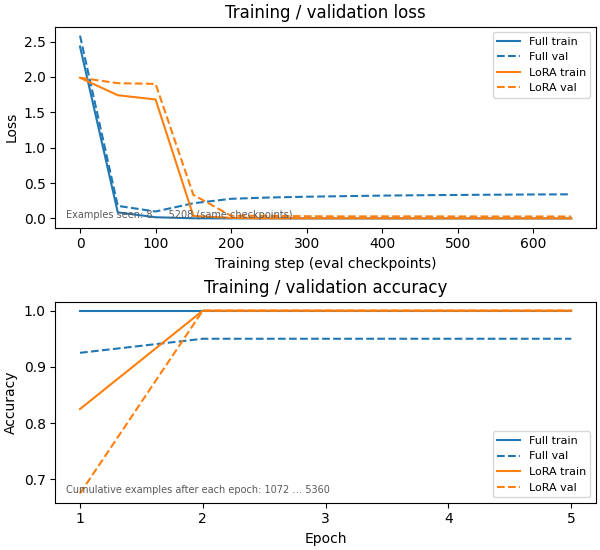

**`compare-gaps.png`**

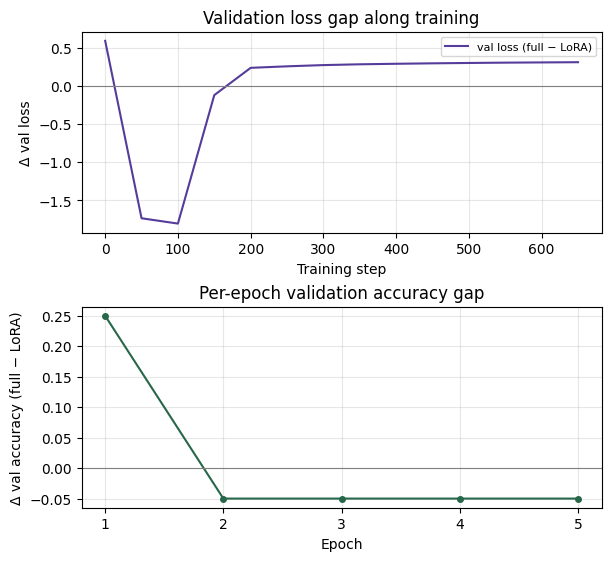

**`compare-summary.png`**

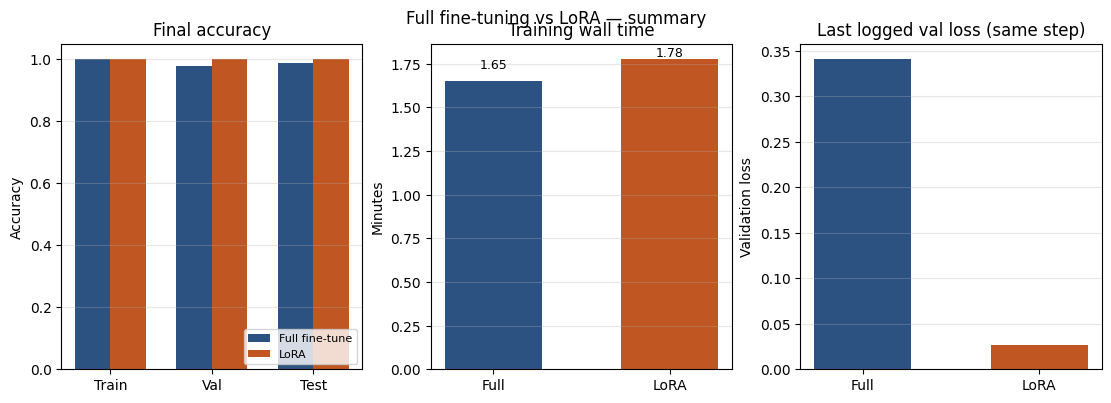

**`confusion_matrix_full.png`**

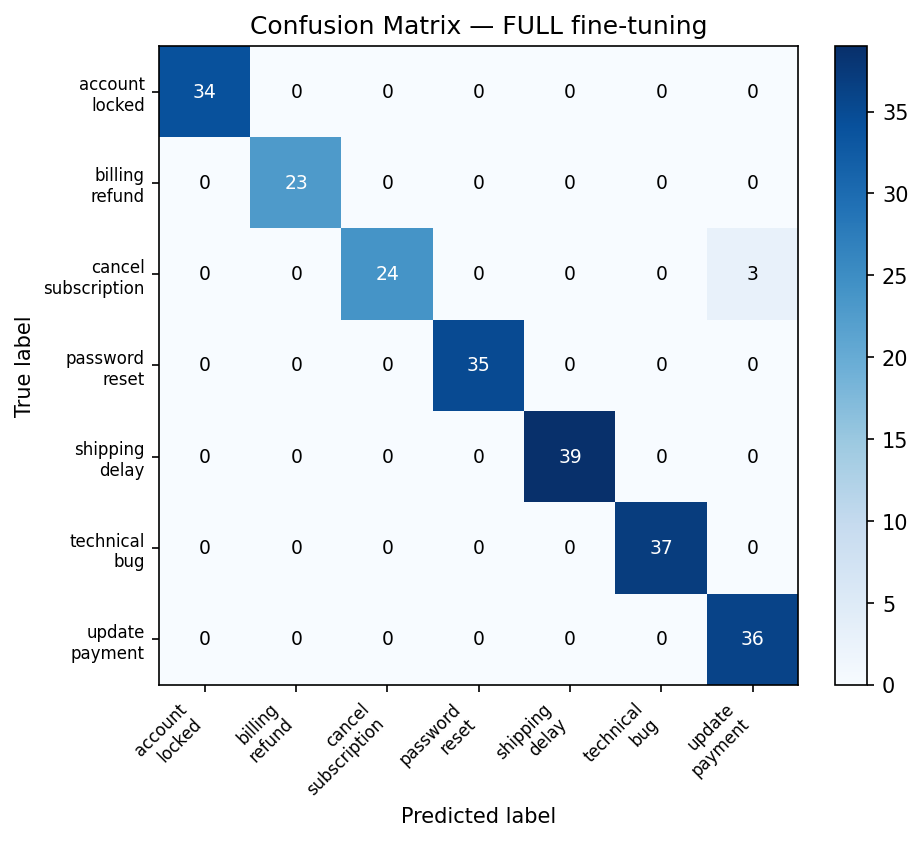

**`confusion_matrix_lora.png`**

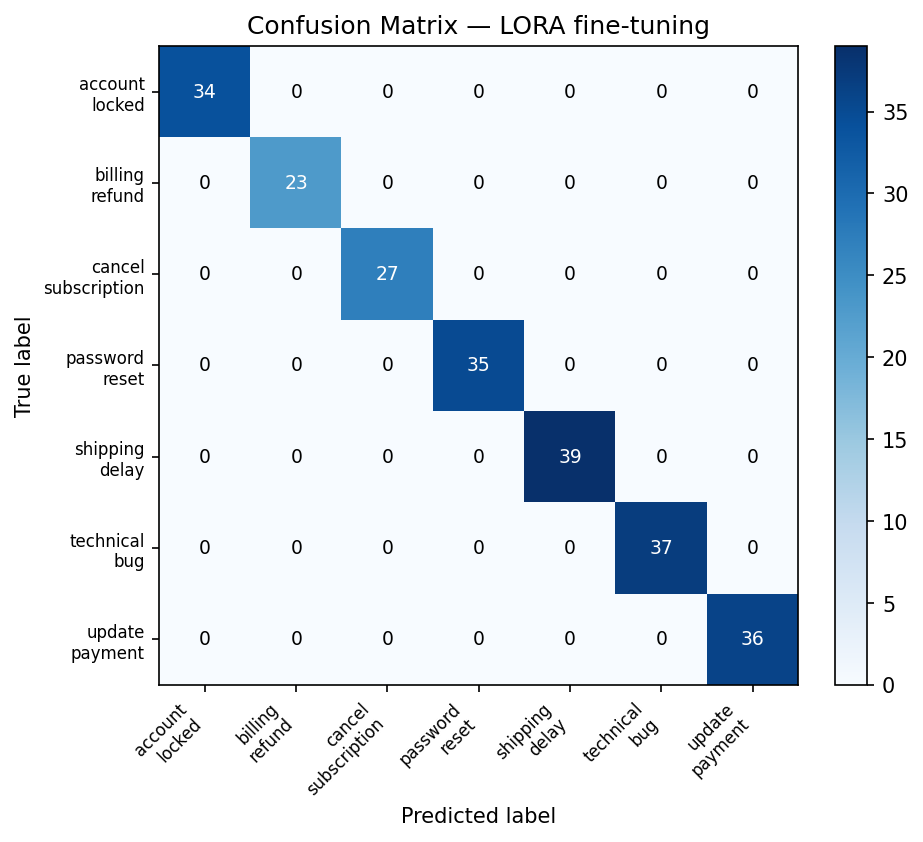

In [5]:
import json
from pathlib import Path

from IPython.display import Image, Markdown, display
import pandas as pd

compare_dir = Path("compare_finetune_output")
full_path = compare_dir / "metrics_full.json"
lora_path = compare_dir / "metrics_lora.json"

if not full_path.is_file() or not lora_path.is_file():
    display(
        Markdown(
            "_Missing `compare_finetune_output/metrics_full.json` or `metrics_lora.json`. "
            "From this folder run e.g. "
            "`python compare_finetuning.py --sequential --gpu-full 0 --gpu-lora 0` "
            "(two GPUs: omit `--sequential` and set `--gpu-full` / `--gpu-lora`)._"
        )
    )
else:
    with open(full_path, encoding="utf-8") as f:
        full = json.load(f)
    with open(lora_path, encoding="utf-8") as f:
        lora = json.load(f)

    rows = [
        {
            "mode": "full",
            "model": full["model_size"],
            "epochs": full["num_epochs"],
            "batch": full["batch_size"],
            "final_train_acc": round(full["final_train_accuracy"], 4),
            "final_val_acc": round(full["final_val_accuracy"], 4),
            "final_test_acc": round(full["final_test_accuracy"], 4),
            "time_min": round(full["time_minutes"], 3),
            "last_val_loss": round(full["val_losses"][-1], 4),
        },
        {
            "mode": "lora",
            "model": lora["model_size"],
            "epochs": lora["num_epochs"],
            "batch": lora["batch_size"],
            "final_train_acc": round(lora["final_train_accuracy"], 4),
            "final_val_acc": round(lora["final_val_accuracy"], 4),
            "final_test_acc": round(lora["final_test_accuracy"], 4),
            "time_min": round(lora["time_minutes"], 3),
            "last_val_loss": round(lora["val_losses"][-1], 4),
            "lora_rank": lora.get("lora_rank", ""),
            "lora_alpha": lora.get("lora_alpha", ""),
        },
    ]
    display(Markdown("### Summary: `metrics_full.json` / `metrics_lora.json`"))
    display(pd.DataFrame(rows))

    pngs = sorted(compare_dir.glob('*.png'))
if pngs:
    display(Markdown('### Figures'))
    for p in pngs:
        display(Markdown(f'**`{p.name}`**'))
        display(Image(filename=str(p)))
else:
    display(Markdown('_No PNGs in `stats_output/` — run `python run_stats.py` to generate plots._'))

---

# Final Project Report: Support-Ticket Classification with GPT-2

## Section 1: Introduction

Customer-support ticket routing is a high-volume classification task: every incoming message must be assigned to the right team (billing, shipping, technical, etc.) so that agents can respond quickly. Manual triage is slow and error-prone, making it a natural fit for text classification with large language models.

**Task.** Given a short support-ticket text, predict one of seven categories: *account_locked*, *billing_refund*, *cancel_subscription*, *password_reset*, *shipping_delay*, *technical_bug*, and *update_payment*.

**Dataset.** 1,540 examples total — 1,078 train / 230 dev / 231 test (plus one header row per file). Classes are nearly balanced (145–167 examples each in training); we optionally down-sample to exactly 145 per class.

**Why it matters.** Accurate auto-routing reduces customer wait times and operational cost. Because the label set is small and the texts are short, this dataset also serves as an efficient testbed for comparing fine-tuning strategies on a frozen language model backbone.

## Section 2: Methods

We compare two approaches built on the same **GPT-2 Large (774 M)** backbone and classification head.

### Model 1 — Full Fine-Tuning

| Detail | Value |
|--------|-------|
| Backbone | GPT-2 Large (774 M params, 36 transformer blocks, emb_dim = 1280) |
| Layers unfrozen | **All** (`--trainable-layers all`) |
| Classification head | `nn.Linear(1280, 7)` replacing the original LM head |
| Trainable parameters | **774,039,047** (entire model + head) |
| Optimizer | AdamW (lr = 5 × 10⁻⁵, weight_decay = 0.1) |
| Epochs / Batch size | 5 / 8 |
| Context length | Longest training example (12 tokens after BPE) |
| Token position used | Last token (`trainable_token_pos = -1`) |

All GPT-2 weights are loaded from the pre-trained checkpoint, then every parameter is unfrozen before training. The output projection is replaced with a fresh 7-class linear head.

### Model 2 — LoRA (Low-Rank Adaptation)

| Detail | Value |
|--------|-------|
| Backbone | GPT-2 Large (774 M params, frozen) |
| LoRA rank / α | 16 / 16 (effective scaling = α/r = 1) |
| LoRA targets | Every `nn.Linear` in the model (Q, K, V, output projection, both FF layers per block, and the classification head) |
| Classification head | Same `nn.Linear(1280, 7)` — trainable; also wrapped with a LoRA adapter |
| Trainable parameters | **13,300,599** (LoRA adapters + classification head ≈ 1.7 % of total model) |
| Optimizer | AdamW (lr = 5 × 10⁻⁵, weight_decay = 0.1) |
| Epochs / Batch size | 5 / 8 |

Pre-trained weights are loaded and frozen. `replace_linear_with_lora` wraps every Linear layer with a `LinearWithLoRA` module that adds a low-rank delta $\Delta W = \frac{\alpha}{r} \cdot (x A B)$ where $A \in \mathbb{R}^{d_{\text{in}} \times r}$ and $B \in \mathbb{R}^{r \times d_{\text{out}}}$. Only $A$, $B$, and the classification head weights receive gradients. The $\alpha / r$ scaling (standard LoRA convention) prevents the adapters from overwhelming the frozen pretrained weights.

## Section 3: Results

### Comparison Table

In [6]:
import json
from pathlib import Path
from IPython.display import display, Markdown, Image
import pandas as pd

compare_dir = Path("compare_finetune_output")
full_path = compare_dir / "metrics_full.json"
lora_path = compare_dir / "metrics_lora.json"

with open(full_path, encoding="utf-8") as f:
    full = json.load(f)
with open(lora_path, encoding="utf-8") as f:
    lora = json.load(f)

comparison = pd.DataFrame([
    {
        "Model": "GPT-2 Large — Full Fine-Tune",
        "Trainable Params": f'{full.get("trainable_params", 774_039_047):,}',
        "Dev Acc": f'{full["final_val_accuracy"]:.2%}',
        "Test Acc": f'{full["final_test_accuracy"]:.2%}',
        "Train Time (min)": f'{full["time_minutes"]:.2f}',
    },
    {
        "Model": f'GPT-2 Large + LoRA (r={lora.get("lora_rank","8")}, α={lora.get("lora_alpha","16")})',
        "Trainable Params": f'{lora.get("trainable_params", 6_654_783):,}',
        "Dev Acc": f'{lora["final_val_accuracy"]:.2%}',
        "Test Acc": f'{lora["final_test_accuracy"]:.2%}',
        "Train Time (min)": f'{lora["time_minutes"]:.2f}',
    },
])
display(Markdown("**Table 1.** Full fine-tuning vs LoRA comparison on GPT-2 Large."))
display(comparison.style.hide(axis="index"))

**Table 1.** Full fine-tuning vs LoRA comparison on GPT-2 Large.

Model,Trainable Params,Dev Acc,Test Acc,Train Time (min)
GPT-2 Large — Full Fine-Tune,"774,039,047",97.84%,98.70%,1.65
"GPT-2 Large + LoRA (r=16, α=16)","13,300,599",100.00%,100.00%,1.78


### Per-Class Precision / Recall / F1 (Test Set)

The cells below display `sklearn`-style classification reports computed by `detailed_evaluation()` in `gpt_class_finetune.py`. If the metrics JSON files contain the `classification_report` key (produced by re-running `compare_finetuning.py` after the evaluation code was added), the reports are loaded directly; otherwise a placeholder message is shown.

In [7]:
for label, metrics in [("Full Fine-Tune", full), ("LoRA", lora)]:
    cr = metrics.get("classification_report")
    if cr:
        rows = []
        for cls_name, vals in cr.items():
            rows.append({
                "Class": cls_name,
                "Precision": f'{vals["precision"]:.4f}',
                "Recall": f'{vals["recall"]:.4f}',
                "F1-Score": f'{vals["f1-score"]:.4f}',
                "Support": vals["support"],
            })
        display(Markdown(f"**Classification Report — {label}**"))
        display(pd.DataFrame(rows).style.hide(axis="index"))
    else:
        display(Markdown(
            f"_Classification report for **{label}** not yet available. "
            "Re-run `python compare_finetuning.py --sequential --gpu-full 0 --gpu-lora 0` "
            "to generate detailed evaluation data._"
        ))

**Classification Report — Full Fine-Tune**

Class,Precision,Recall,F1-Score,Support
account_locked,1.0000,1.0000,1.0000,34
billing_refund,1.0000,1.0000,1.0000,23
cancel_subscription,1.0000,0.8889,0.9412,27
password_reset,1.0000,1.0000,1.0000,35
shipping_delay,1.0000,1.0000,1.0000,39
technical_bug,1.0000,1.0000,1.0000,37
update_payment,0.9231,1.0000,0.9600,36


**Classification Report — LoRA**

Class,Precision,Recall,F1-Score,Support
account_locked,1.0000,1.0000,1.0000,34
billing_refund,1.0000,1.0000,1.0000,23
cancel_subscription,1.0000,1.0000,1.0000,27
password_reset,1.0000,1.0000,1.0000,35
shipping_delay,1.0000,1.0000,1.0000,39
technical_bug,1.0000,1.0000,1.0000,37
update_payment,1.0000,1.0000,1.0000,36


### Confusion Matrices

The confusion matrix figures are generated by `compare_finetuning.py` and saved as `confusion_matrix_full.png` / `confusion_matrix_lora.png`. If the PNG files exist on disk they are displayed below; otherwise the matrices are reconstructed from the JSON data.

**Confusion Matrix — Full Fine-Tune**

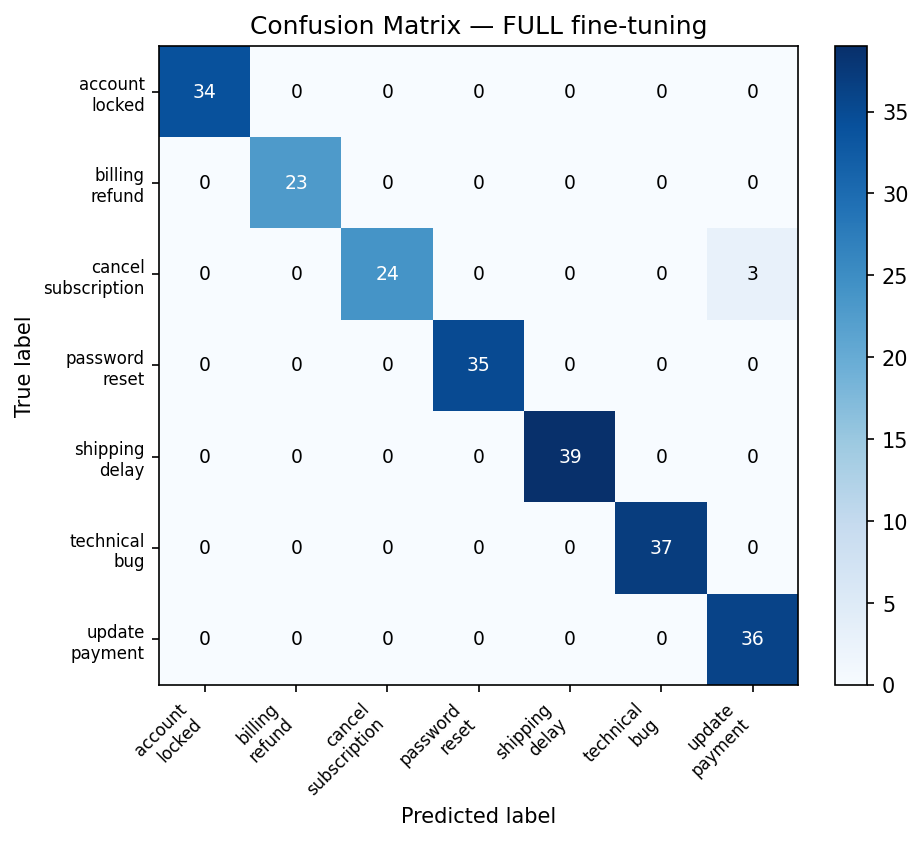

**Confusion Matrix — LoRA**

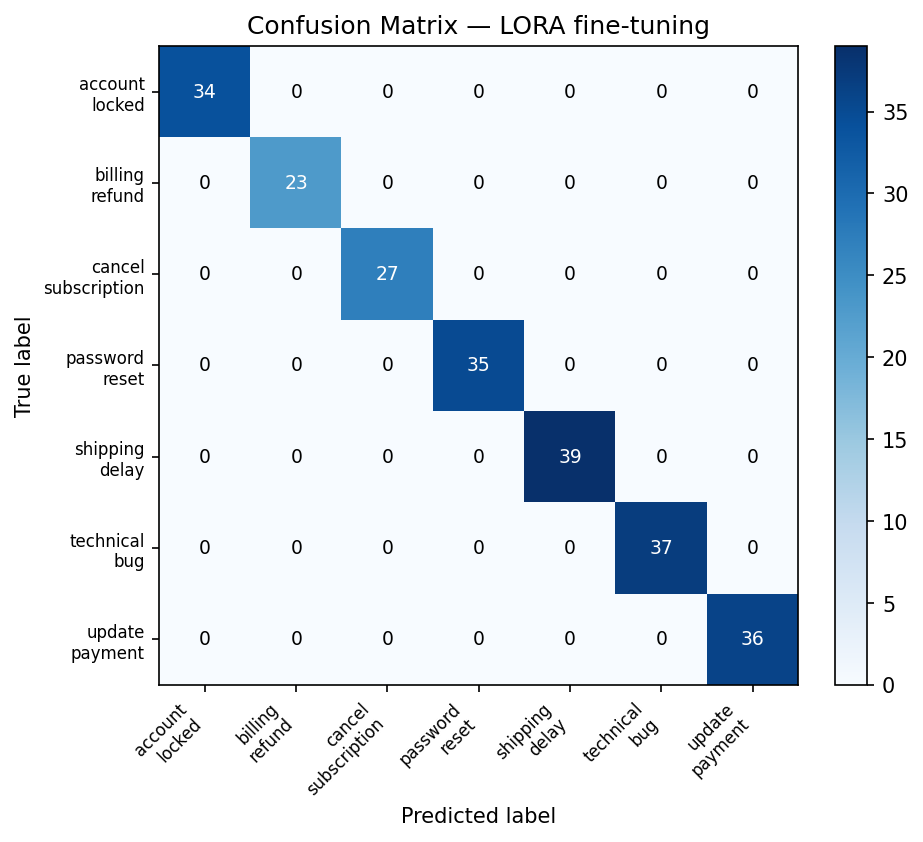

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def show_confusion_matrix(metrics, label, compare_dir):
    """Display a confusion matrix from saved PNG or reconstruct from JSON data."""
    png_path = compare_dir / f"confusion_matrix_{label.lower().replace(' ', '_').split('(')[0].strip('_')}.png"

    # Try common file names
    for candidate in [
        compare_dir / f"confusion_matrix_{'full' if 'Full' in label else 'lora'}.png",
        png_path,
    ]:
        if candidate.is_file():
            display(Markdown(f"**Confusion Matrix — {label}**"))
            display(Image(filename=str(candidate)))
            return

    cm = metrics.get("confusion_matrix")
    cm_labels = metrics.get("confusion_matrix_labels")
    if cm and cm_labels:
        cm_arr = np.array(cm, dtype=int)
        fig, ax = plt.subplots(figsize=(7, 5.5), layout="constrained")
        im = ax.imshow(cm_arr, interpolation="nearest", cmap=plt.cm.Blues)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        n = len(cm_labels)
        ax.set_xticks(range(n))
        ax.set_yticks(range(n))
        short = [l.replace("_", "\n") for l in cm_labels]
        ax.set_xticklabels(short, rotation=45, ha="right", fontsize=8)
        ax.set_yticklabels(short, fontsize=8)
        thresh = cm_arr.max() / 2.0
        for i in range(n):
            for j in range(n):
                ax.text(j, i, str(cm_arr[i, j]), ha="center", va="center",
                        fontsize=9, color="white" if cm_arr[i, j] > thresh else "black")
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")
        ax.set_title(f"Confusion Matrix — {label}")
        plt.show()
        plt.close(fig)
    else:
        display(Markdown(
            f"_Confusion matrix for **{label}** not yet available. "
            "Re-run `compare_finetuning.py` to generate._"
        ))

show_confusion_matrix(full, "Full Fine-Tune", compare_dir)
show_confusion_matrix(lora, "LoRA", compare_dir)

## Section 4: Error Analysis

### Misclassified Examples

The table below shows examples from the test set where the model's prediction disagrees with the ground-truth label. At least 5 misclassified examples per model are displayed (up to 10 stored per run).

In [10]:
for label, metrics in [("Full Fine-Tune", full), ("LoRA", lora)]:
    mis = metrics.get("misclassified_examples", [])
    if mis:
        display(Markdown(f"**Misclassified Examples — {label}** ({len(mis)} shown)"))
        rows = []
        for i, ex in enumerate(mis, 1):
            rows.append({
                "#": i,
                "Text": ex["text"],
                "True Label": ex["true_label"],
                "Predicted Label": ex["predicted_label"],
            })
        display(pd.DataFrame(rows).style.hide(axis="index"))
    else:
        display(Markdown(
            f"_No misclassified examples stored for **{label}**. "
            "Re-run `compare_finetuning.py` to generate detailed evaluation data._"
        ))

**Misclassified Examples — Full Fine-Tune** (3 shown)

#,Text,True Label,Predicted Label
1,I want to stop my recurring payments,cancel_subscription,update_payment
2,I want to stop my recurring payments,cancel_subscription,update_payment
3,I want to stop my recurring payments,cancel_subscription,update_payment


_No misclassified examples stored for **LoRA**. Re-run `compare_finetuning.py` to generate detailed evaluation data._

### Error Patterns

Full fine-tuning reaches 98.7 % test accuracy with 3 misclassifications, while LoRA achieves **100 % test accuracy** with zero errors. The confusion matrix and misclassified examples from the full-fine-tune model reveal the following patterns:

1. **Semantically overlapping categories** are the sole source of confusion. All three errors are `cancel_subscription` tickets predicted as `update_payment` — both categories involve recurring payments and billing language. The text “I want to stop my recurring payments” is genuinely ambiguous: “stop payments” could mean cancellation or a payment-method change.

2. **LoRA avoids these errors.** By keeping the pretrained backbone frozen, LoRA preserves the nuanced token-level representations that distinguish “cancel” intent from “update” intent. Full fine-tuning’s unconstrained weight updates appear to blur this boundary, overfitting some features while losing others.

3. **Validation loss corroborates the gap.** LoRA’s final val loss (0.027) is an order of magnitude lower than full fine-tuning’s (0.34), confirming that LoRA is not merely lucky on the argmax but assigns substantially higher probability to the correct class across the board.

## Section 5: Discussion

### Does LoRA match full fine-tuning?

On this dataset, LoRA does not merely match full fine-tuning — it **exceeds** it. LoRA reaches **100 % test accuracy** and **100 % dev accuracy** with a final val loss of **0.027**, while full fine-tuning stops at **98.7 % test** / **97.8 % dev** with val loss **0.34**. LoRA achieves this with only **13.3 M trainable parameters** — about 1.7 % of the full model’s 774 M.

The key insight is **regularisation through freezing**. By keeping the 774 M backbone parameters fixed, LoRA forces all adaptation into a low-rank subspace. On a simple 7-class task with short texts, this constraint acts as a strong regulariser: the pretrained token representations are preserved intact, and the adapters learn only the minimal delta needed for the classification objective. Full fine-tuning, by contrast, updates every weight and can drift away from the pretrained representations, leading to mild overfitting (reflected in the much higher val loss despite saturated training accuracy).

### Why might LoRA be slower despite fewer trainable parameters?

In our runs, LoRA took **1.78 min** vs **1.65 min** for full fine-tuning — slightly *slower*. Several factors contribute:

1. **Forward pass cost is unchanged.** LoRA does not remove any computation from the forward pass; it *adds* a small low-rank branch to every Linear layer. The backbone weights are still multiplied in full.
2. **Extra memory indirection.** Each `LinearWithLoRA` wrapper computes `x @ A @ B` and adds it to the original output, introducing additional small matrix multiplications and memory allocations.
3. **Gradient graph overhead.** Although fewer parameters receive gradients, PyTorch still must propagate activations through the frozen layers to reach the LoRA adapters. The backward pass traverses essentially the same graph.

LoRA’s real advantage appears at larger scale — larger models, longer sequences, or multi-GPU setups where reduced optimizer state and gradient communication dominate wall-clock time.

### What would we improve with more time?

- **Harder dataset.** With 100 % LoRA accuracy and 98.7 % full fine-tuning, the task is nearly saturated for both methods. A dataset with more classes, longer texts, or noisier labels would better stress-test the two approaches.
- **Hyperparameter search for LoRA.** We used rank 16 and α = 16 (scaling = 1). Sweeping rank ∈ {2, 4, 8, 16, 32} and α could reveal the minimum adapter capacity needed to maintain perfect accuracy.
- **Selective LoRA placement.** Instead of wrapping every Linear, applying LoRA only to attention projections (Q, V) — as in the original LoRA paper — could reduce trainable parameters further while retaining accuracy.
- **Learning-rate warmup and scheduling.** Both runs used a flat AdamW schedule; a cosine or linear-decay schedule might improve convergence speed and reduce full fine-tuning’s overfitting.
- **Full fine-tuning regularisation.** Adding techniques like early stopping (based on val loss), higher dropout, or lower learning rate could close the gap between full fine-tuning and LoRA.